In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
import pandas as pd

yahoo = pd.read_excel("yahoo_data.xlsx")

capital_market = pd.read_csv("capital_market_dataset.csv")

corporate_actions = pd.read_csv("corporate_actions.csv")

In [3]:
yahoo.head()

capital_market.head()

corporate_actions.head()

,Security,Action_Type,Date,Impact
0,AAPL,Dividend,2023-03-01,0.85
1,TSLA,Stock Split,2022-08-24,2:1
2,AMZN,Split,2022-06-06,20:1
3,MSFT,Dividend,2023-02-15,0.68
4,GOOGL,Dividend,2023-03-10,0.75


In [4]:
yahoo.info()
capital_market.info()
corporate_actions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1258 non-null   str    
 1   Open         1258 non-null   float64
 2   High         1258 non-null   float64
 3   Low          1258 non-null   float64
 4   Close*       1258 non-null   float64
 5   Adj Close**  1258 non-null   float64
 6   Volume       1258 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 68.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 18870 entries, 0 to 18869
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18870 non-null  str    
 1   Open          18870 non-null  float64
 2   High          18870 non-null  float64
 3   Low           18870 non-null  float64
 4   Close         18870 non-null  float64
 5   Adj_Close     18870 non-null  float64
 6   Volume        18870 n

In [5]:
print("Yahoo records:", len(yahoo))
print("Capital Market records:", len(capital_market))
print("Corporate Actions:", len(corporate_actions))

Yahoo records: 1258
Capital Market records: 18870
Corporate Actions: 6


In [6]:
yahoo.isnull().sum()

capital_market.isnull().sum()

corporate_actions.isnull().sum()

Security       0
Action_Type    0
Date           0
Impact         0
dtype: int64

In [7]:
yahoo = yahoo.ffill()
capital_market = capital_market.ffill()
corporate_actions = corporate_actions.ffill()

In [8]:
yahoo.columns = yahoo.columns.str.replace('*','', regex=False)
yahoo.columns = yahoo.columns.str.replace(' ','_')

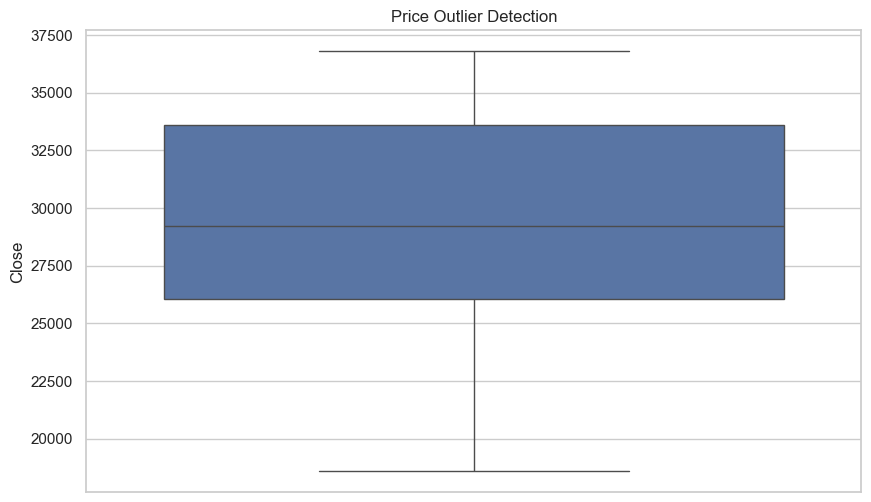

In [9]:
sns.boxplot(y=yahoo['Close'])
plt.title("Price Outlier Detection")
plt.show()

In [10]:
yahoo.describe()

,Open,High,Low,Close,Adj_Close,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,29595.823045,29776.945739,29402.432226,29599.361677,29599.361677,3.450636e+08
std,4006.078299,4009.007573,4004.949066,4007.468822,4007.468822,1.069142e+08
min,19028.360000,19121.010000,18213.650000,18591.930000,18591.930000,8.615000e+07
25%,26041.267500,26163.155000,25877.872500,26027.120000,26027.120000,2.773125e+08
50%,29201.410000,29335.685000,28996.500000,29199.460000,29199.460000,3.247250e+08
75%,33604.027500,33825.445000,33346.827500,33600.342500,33600.342500,3.875100e+08
max,36722.600000,36952.650000,36636.000000,36799.650000,36799.650000,9.159900e+08


In [11]:
yahoo['Daily_Return'] = yahoo['Close'].pct_change()

In [12]:
yahoo['Volatility'] = yahoo['Daily_Return'].rolling(window=20).std()

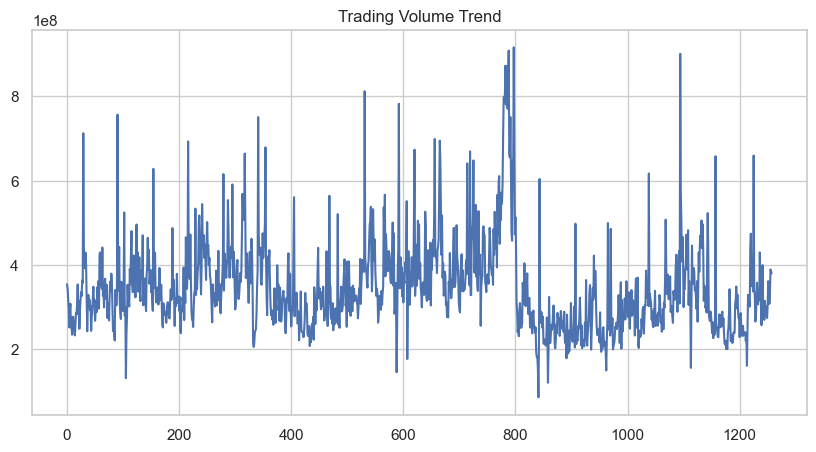

In [13]:
yahoo['Volume'].plot(figsize=(10,5))
plt.title("Trading Volume Trend")
plt.show()

In [14]:
market_data = pd.merge(
    yahoo,
    capital_market,
    how="left"
)

In [15]:
market_data.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,Daily_Return,Volatility,Security,Asset_Type,Price_Change
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000,NaN,NaN,NaN,NaN,NaN
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000,-0.007977,NaN,NaN,NaN,NaN
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000,-0.015500,NaN,NaN,NaN,NaN
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000,0.006875,NaN,NaN,NaN,NaN
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000,0.010276,NaN,NaN,NaN,NaN


In [16]:
market_data.to_csv("outputs/clean_market_data.csv", index=False)

In [17]:
market_data = pd.read_csv("outputs/clean_market_data.csv")

market_data.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,Daily_Return,Volatility,Security,Asset_Type,Price_Change
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000,NaN,NaN,NaN,NaN,NaN
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000,-0.007977,NaN,NaN,NaN,NaN
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000,-0.015500,NaN,NaN,NaN,NaN
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000,0.006875,NaN,NaN,NaN,NaN
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000,0.010276,NaN,NaN,NaN,NaN


In [18]:
market_data['Date'] = pd.to_datetime(market_data['Date'])

market_data = market_data.sort_values('Date')

In [19]:
market_data.set_index('Date', inplace=True)

In [20]:
market_data['Daily_Return'] = market_data['Close'].pct_change()

In [21]:
market_data['20_MA'] = market_data['Close'].rolling(window=20).mean()
market_data['50_MA'] = market_data['Close'].rolling(window=50).mean()

In [22]:
market_data['Volatility'] = market_data['Daily_Return'].rolling(20).std()

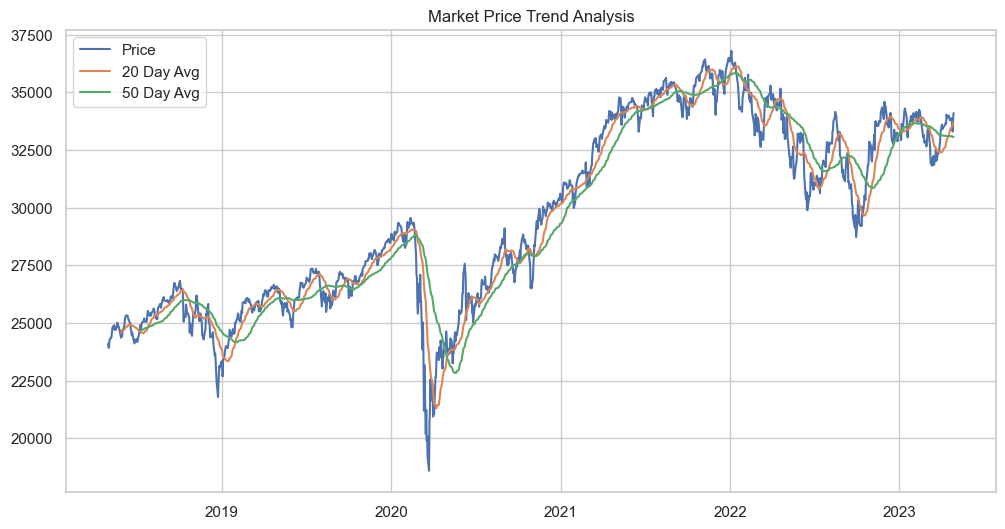

In [23]:
plt.figure(figsize=(12,6))

plt.plot(market_data['Close'], label='Price')
plt.plot(market_data['20_MA'], label='20 Day Avg')
plt.plot(market_data['50_MA'], label='50 Day Avg')

plt.title("Market Price Trend Analysis")
plt.legend()
plt.show()

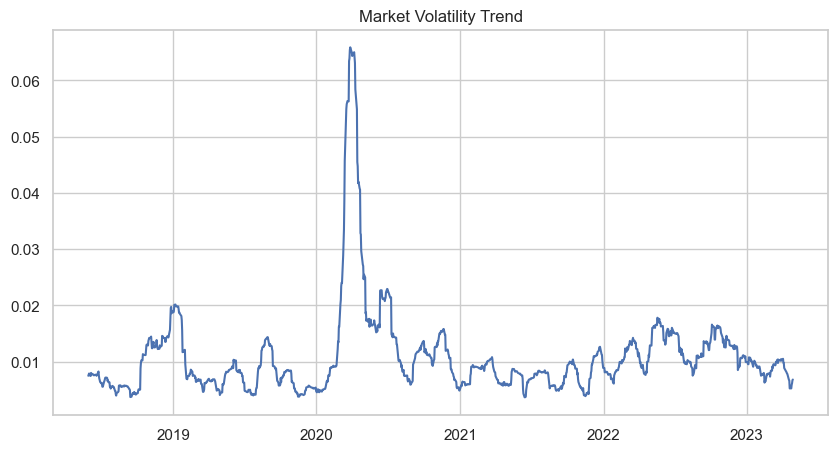

In [24]:
plt.figure(figsize=(10,5))

plt.plot(market_data['Volatility'])

plt.title("Market Volatility Trend")

plt.show()

In [25]:
market_data.sort_values('Volume', ascending=False).head(10)

,Open,High,Low,Close,Adj_Close,Volume,Daily_Return,Volatility,Security,Asset_Type,Price_Change,20_MA,50_MA
Date,,,,,,,,,,,,,
2020-02-28,25270.83,25494.24,24681.01,25409.36,25409.36,915990000,-0.013866,0.016168,NaN,NaN,NaN,28506.5465,28660.5496
2020-03-12,22184.71,22837.95,21154.46,21200.62,21200.62,908260000,-0.099884,0.038634,NaN,NaN,NaN,26705.5210,28044.2778
2018-12-21,22871.74,23254.59,22396.34,22445.37,22445.37,900510000,-0.018121,0.014657,NaN,NaN,NaN,24401.2340,24914.1782
2020-03-20,20253.15,20531.26,19094.27,19173.98,19173.98,872290000,-0.045462,0.056339,NaN,NaN,NaN,24113.4015,27078.2246
2020-03-18,20188.69,20489.33,18917.46,19898.92,19898.92,871360000,-0.063024,0.055774,NaN,NaN,NaN,25060.9625,27439.5766
2020-03-13,21973.82,23189.76,21285.37,23185.62,23185.62,843080000,0.093629,0.045717,NaN,NaN,NaN,26393.6365,27937.2214
2021-03-19,32858.36,32858.36,32505.07,32627.97,32627.97,811890000,-0.007131,0.010512,NaN,NaN,NaN,31972.7160,31413.0828
2020-03-24,19722.19,20737.70,19649.25,20704.91,20704.91,799340000,0.113650,0.063433,NaN,NaN,NaN,23326.1355,26708.5480
2020-03-25,21050.34,22019.93,20538.34,21200.55,21200.55,796320000,0.023938,0.063913,NaN,NaN,NaN,23038.2835,26554.4180


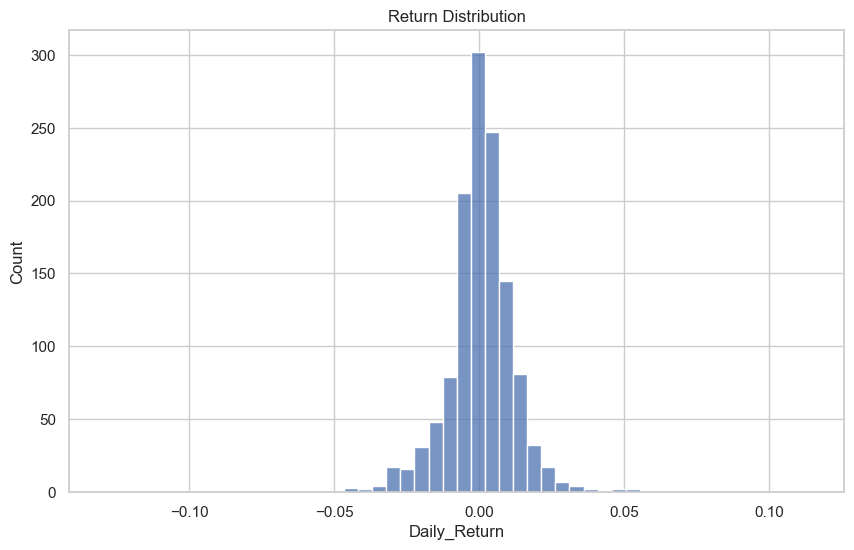

In [26]:
sns.histplot(market_data['Daily_Return'], bins=50)

plt.title("Return Distribution")

plt.show()

In [27]:
market_data['Daily_Return'].max()

market_data['Daily_Return'].min()

np.float64(-0.12926546713005727)

In [28]:
market_data['Risk_Index'] = market_data['Volatility'] * 100

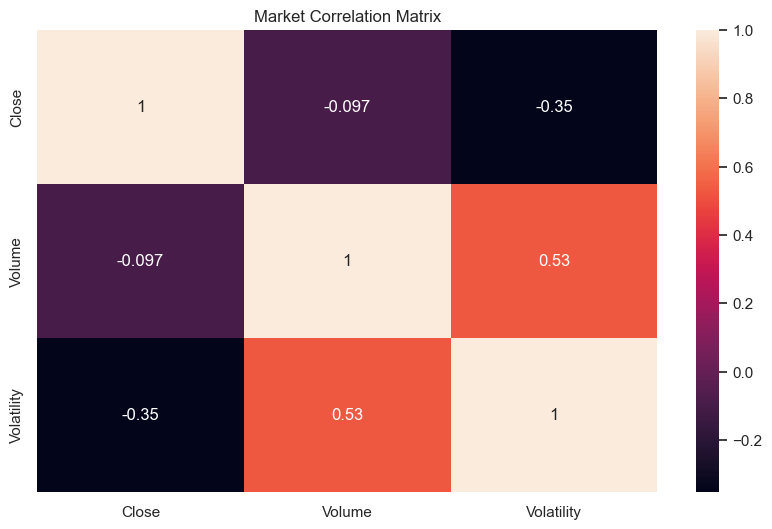

In [29]:
correlation = market_data[['Close','Volume','Volatility']].corr()

sns.heatmap(correlation, annot=True)

plt.title("Market Correlation Matrix")

plt.show()

In [30]:
market_data.to_csv("outputs/market_kpi_dataset.csv")

In [31]:
import sqlite3

In [32]:
conn = sqlite3.connect("capital_market.db")

In [33]:
market_data.to_sql(
    "market_prices",
    conn,
    if_exists="replace",
    index=True
)

1258

In [34]:
pd.read_sql("""
SELECT *
FROM market_prices
LIMIT 5
""", conn)

,Date,Open,High,Low,Close,Adj_Close,Volume,Daily_Return,Volatility,Security,Asset_Type,Price_Change,20_MA,50_MA,Risk_Index
0,2018-05-01 00:00:00,24117.29,24117.29,23808.19,24099.05,24099.05,380070000,NaN,None,None,None,None,None,None,None
1,2018-05-02 00:00:00,24097.63,24185.52,23886.30,23924.98,23924.98,385350000,-0.007223,None,None,None,None,None,None,None
2,2018-05-03 00:00:00,23836.23,23996.15,23531.31,23930.15,23930.15,389240000,0.000216,None,None,None,None,None,None,None
3,2018-05-04 00:00:00,23865.22,24333.35,23778.87,24262.51,24262.51,329480000,0.013889,None,None,None,None,None,None,None
4,2018-05-07 00:00:00,24317.66,24479.45,24263.42,24357.32,24357.32,307670000,0.003908,None,None,None,None,None,None,None


In [35]:
pd.read_sql("""
SELECT COUNT(*) AS total_records
FROM market_prices
""", conn)

,total_records
0,1258


In [36]:
pd.read_sql("""
SELECT *
FROM market_prices
WHERE Close IS NULL
""", conn)

,Date,Open,High,Low,Close,Adj_Close,Volume,Daily_Return,Volatility,Security,Asset_Type,Price_Change,20_MA,50_MA,Risk_Index


In [37]:
pd.read_sql("""
SELECT *
FROM market_prices
WHERE Close <= 0
""", conn)

,Date,Open,High,Low,Close,Adj_Close,Volume,Daily_Return,Volatility,Security,Asset_Type,Price_Change,20_MA,50_MA,Risk_Index


In [38]:
pd.read_sql("""
SELECT Date, Close, Volatility
FROM market_prices
ORDER BY Volatility DESC
LIMIT 10
""", conn)

,Date,Close,Volatility
0,2020-03-27 00:00:00,21636.78,0.065884
1,2020-03-26 00:00:00,22552.17,0.065413
2,2020-03-30 00:00:00,22327.48,0.065154
3,2020-04-06 00:00:00,22679.99,0.065017
4,2020-03-31 00:00:00,21917.16,0.064999
5,2020-04-03 00:00:00,21052.53,0.064500
6,2020-04-02 00:00:00,21413.44,0.064470
7,2020-04-01 00:00:00,20943.51,0.064343
8,2020-04-07 00:00:00,22653.86,0.063969
9,2020-03-25 00:00:00,21200.55,0.063913


In [39]:
pd.read_sql("""
SELECT Date, Volume
FROM market_prices
ORDER BY Volume DESC
LIMIT 10
""", conn)

,Date,Volume
0,2020-02-28 00:00:00,915990000
1,2020-03-12 00:00:00,908260000
2,2018-12-21 00:00:00,900510000
3,2020-03-20 00:00:00,872290000
4,2020-03-18 00:00:00,871360000
5,2020-03-13 00:00:00,843080000
6,2021-03-19 00:00:00,811890000
7,2020-03-24 00:00:00,799340000
8,2020-03-25 00:00:00,796320000
9,2020-03-17 00:00:00,793060000


In [40]:
pd.read_sql("""
SELECT Date, COUNT(*)
FROM market_prices
GROUP BY Date
HAVING COUNT(*) > 1
""", conn)

,Date,COUNT(*)


In [41]:
pd.read_sql("""
SELECT AVG(Close) AS avg_price
FROM market_prices
""", conn)

,avg_price
0,29599.361677


In [42]:
pd.read_sql("""
SELECT MAX(Close) AS highest_price
FROM market_prices
""", conn)

,highest_price
0,36799.65


In [43]:
market_data.to_csv(
    "outputs/validated_market_data.csv"
)